# Trade-Off Support Tool

This notebook implements a flexible framework using multiple pathways to allow flexibility of:
- Weighted scoring
- Analytical Hierarchy Process (AHP)
- User-defined or preset weightings

The tool is designed to:
- Support decision-making for Nature-Based Solutions (NbS)
- Allow comparison between scenarios
- Highlight trade-offs between competing objectives
Highlight conflcits of interest between the tool and literature and studies

Outputs of graphs and tables are designed to support the decision-making process and evalaute trade-offs, both of which are raised as industry wide challenges.




*Operational cells below, please refer to Step 1*

In [ ]:
# Import libraries into python to to support onward function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Create simple print functions to improve readability for user
def print_title(title):
  #Prints a main title
    print("\n" + "="*60)
    print(title)
    print("="*60)

def print_subtitle(subtitle):
  #prints a formatted subtitle
    print("\n" + "-"*60)
    print(subtitle)
    print("-"*60)

def print_note(text):
  """Prints a simple note for user guidance."""
  print(f"\nNote: {text}")

# Can alter Criteria if necessary here:

These criteria are used to evaluate each intervention, designed to reflect environmental beenfits, economic factors and feasibility.

These criteria form the basis of the AHP weighting generation, and will be compared to create pairwise outcomes.

In [ ]:
#Define criteria to be evaluated
#If these are altered, ensure consistency with formating and names used, trhoughout the code.

criteria = [
    "Storage",
    "Habitat",
    "Carbon",
    "Cost",
    "Cost-Effectiveness",
    "Time to Effectiveness",
    "Durability",
    "Stakeholder Risk",
    "Policy Alignment",
    "Disservices Risk"
]

# **Start Here: Select a route**
This will depend on your preferences, and resources available.

**Step 1: Please chose a weighting route**

There are three options for routes:

1. **Preset weighting**  
   Uses predefined stakeholder-style priorities.

2. **Upload weighting or pairwise matrix**  
   Allows an upload of saved CSV file.

3. **Create a new AHP matrix**  
   Builds a new pairwise comparison matrix interactively in Python.

The output from this section is a single weighting vector called `weights`, which is then used throughout the rest of the analysis to evalaute your trade-offs.

Re-run the cell below if seeking to change route

In [ ]:
# Displays a message to allow route selection
# will show and explain the three route options

print_subtitle("Step 1: Select a weighting route")

route = input(
    "Write '1' for using a stakeholder-specific preset, '2' for upload of your own pre-made pairwise or weighting, or '3' to create a new AHP within python: "
).strip()

# Initialize matrix to None, as it might not be defined by all routes
matrix = None

if route == "1":
    print("\nPreset AHP selected.")
elif route == "2":
    print("\nUpload route selected.")
elif route == "3":
    print("\nCreate a new AHP selected.") #these are the route options
else:
    raise ValueError("Invalid selection. Please rerun and enter 1, 2, or 3.")


------------------------------------------------------------
Step 1: Select a weighting route
------------------------------------------------------------
Write '1' for using a stakeholder-specific preset, '2' for upload of your own pre-made pairwise or weighting, or '3' to create a new AHP within python: 1

Preset AHP selected.


In [ ]:
# Step 2A: Preset selection route chosen
# next step is to then chose which preset

if route == "1":
    print_subtitle("Step 2A: Choose preset weighting")

    print("1 - Flood-focused")
    print("2 - Carbon-Focussed")
    print("3 - Habitat-Focussed")
    print("4 - Cost-Focussed")
    print("5 - Policy-Focussed")
    print("6 - Land-Owner Perspective")
    print("For a multi-benefit approach determining AHP within this tool is recommended, as it still remains highly perception determined. Re-run the previous cell.")


    preset = input("Enter 1, 2, 3, 4, 5, 6: ").strip()

    if preset == "1":
        weights = np.array([0.1439, 0.07613, 0.0383, 0.0710, 0.0999, 0.0235, 0.1193, 0.1402, 0.123, 0.1645])
        print("\nloaded")

    elif preset == "2": #use of elif allows for conditional outcomes
        weights = np.array([0.0589, 0.0834, 0.2546, 0.0627, 0.0972, 0.0538, 0.1385, 0.0569, 0.1243, 0.0697])
        print("\nCarbon-focused preset loaded")

    elif preset == "3":
        weights = np.array([0.0728, 0.1784, 0.0183, 0.0336, 0.1448, 0.04886, 0.1489, 0.0486, 0.0754, 0.02302])
        print("\nloaded")

    elif preset == "4":
        weights = np.array([0.1922, 0.0205, 0.0224, 0.2499, 0.3035, 0.1225, 0.1345, 0.0289, 0.0623, 0.00363])
        print("\nloaded")

    elif preset == "5":
        weights = np.array([0.1018, 0.0826, 0.0879, 0.0784, 0.0967, 0.0795, 0.1432, 0.1186, 0.1689, 0.0424])
        print("\nPolicy-focused preset loaded")

    elif preset == "6":
        weights = np.array([0.0583, 0.0521, 0.0442, 0.1587, 0.1789, 0.1184, 0.1127, 0.1526, 0.0675, 0.0566])
        print("\nLand-owner perspective preset loaded")

    else: # fall back display to support error diagnostic for user
        raise ValueError("Invalid preset choice")


------------------------------------------------------------
Step 2A: Choose preset weighting
------------------------------------------------------------
1 - Flood-focused
2 - Carbon-Focussed
3 - Habitat-Focussed
4 - Cost-Focussed
5 - Policy-Focussed
6 - Land-Owner Perspective
For a multi-benefit approach determining AHP within this tool is recommended, as it still remains highly perception determined. Re-run the previous cell.
Enter 1, 2, 3, 4, 5, 6: 1

loaded


## Step 2: Proceed with Uploading an AHP.



This is particualarly helpful for repeated inputs of daat for evaluation, speeding up the process.

Two formats are supported:
- A weighting vector (CSV with Criterion + Weight)
- A full AHP pairwise comparison matrix

If a matrix is used, weightings will be calculated through built in functions

In [ ]:
# Step 2B: Upload existing data


if route == "2":
    print_subtitle("Step 2B: Upload weighting or pairwise matrix") #added for clarity

    from google.colab import files
    import io

    print("1 - Upload weighting file")
    print("2 - Upload pairwise matrix")

    upload_type = input("Enter 1 or 2: ").strip() #provides an option box before next stage, this informs the code what processing is required next

    print("\nPlease upload your file:")
    uploaded = files.upload() # allows easy file upload

    # Get uploaded file name
    filename = list(uploaded.keys())[0]

    if upload_type == "1":
        df_weights = pd.read_csv(io.BytesIO(uploaded[filename]))
        weights = df_weights["Weight"].values

        print("\nWeights successfully loaded from uploaded file")

    elif upload_type == "2":
        df_matrix = pd.read_csv(io.BytesIO(uploaded[filename]), index_col=0)
        matrix = df_matrix.values

        # Calculate weights from matrix if a matrix file was input
        col_sum = np.sum(matrix, axis=0)
        norm_matrix = matrix / col_sum
        weights = np.mean(norm_matrix, axis=1)

        print("\nPairwise matrix uploaded and weights calculated")

    else:
        raise ValueError("Invalid upload option")

AHP process written below for clarity and readability.
# **Create new AHP** AlTERNATIVE OPTION

In [ ]:

# Step 2C: Create new AHP

print_note("You will be asked to compare all criteria pairs.")


if route == "3":
    print_subtitle("Step 2C: Create a new AHP")


    n = len(criteria)

    # form a matrix

    matrix = np.ones((n, n)) # n = criteria number
    skipped = [] #for any skipped outputs


    # Input conversion function from before

    def convert_input(value):
        if value == "c": #equal values are given c
            return 1 #when equal, a value of 1 is given
        try:
            val = int(value)
            if val > 0:
                return val
            elif val < 0: #this explains the ranking process for whether scenario A or B is more important, negative values are used for scale

                return 1 / abs(val) # absolute value
        except:
            return None #if the input is invalid, none will be returned, again, support diagnostics

  # Instructions

    print("\n--- AHP Pairwise Comparison ---")
    print("Use the following scale:")
    print("c = equal importance")
    print("1,3,5,7,9 = first is more important")
    print("-1,-3,-5,-7,-9 = second is more important")
    print("a = unsure (will revisit later)\n")


    #  Pairwise comparisons

    for i in range(n):
        for j in range(i + 1, n): #no duplicates or self comparisons, this ensures smooth, efficienct process and ensures each pair is only compared once


            while True:
                print(f"\nCompare: {criteria[i]} vs {criteria[j]}")
                user_input = input("Enter value: ").strip().lower()

                if user_input in ["a", "b"]:
                    skipped.append((i, j))
                    break

                value = convert_input(user_input)

                if value is not None:
                    matrix[i][j] = value
                    matrix[j][i] = 1 / value
                    break
                else:
                    print("Invalid input, try again please.")


    # If anything is missed of skipped, questions are asked again to ensure no missing values, and the overall outcome is representative
    if skipped:
        print("\nRevisiting the skipped comparisons")
        for (i, j) in skipped:
            while True:
                print(f"\nCompare: {criteria[i]} vs {criteria[j]}") #will show the criterai again
                user_input = input("Enter value: ").strip().lower()

                value = convert_input(user_input) #the input is converted here

                if value is not None:
                    matrix[i][j] = value
                    matrix[j][i] = 1 / value #matrix begins to be filled using python matrix functions
                    break
                else:
                    print("Invalid input, try again.")


    # Calculate weights

    col_sum = np.sum(matrix, axis=0) # uses the calculated weights to add each column up
    norm_matrix = matrix / col_sum # normalise matrix for comparability
    weights = np.mean(norm_matrix, axis=1) # Follows standard AHP method by taking row averages

    # Output results

    print("\nFinal Weights")
    for i in range(n):
        print(f"{criteria[i]}: {weights[i]:.3f}")

    print(f"\nTotal weight sum: {np.sum(weights):.3f}")


Note: You will be asked to compare all criteria pairs.


In [ ]:
import pandas as pd

# ---------------------------
# Save results (weights + matrix)
# ---------------------------
save_choice = input("\nWould you like to save this weighting? (y/n): ").strip().lower()

if save_choice == "y":
    name = input("Enter a name for this weighting scenario: ").strip()
    safe_name = name.replace(" ", "_")

    # Create DataFrames
    df_weights = pd.DataFrame({
        "Criterion": criteria,
        "Weight": weights
    })

    df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)

    # Define filenames
    weights_file = f"{safe_name}_weights.csv"
    matrix_file = f"{safe_name}_pairwise_matrix.csv"

    # Save files
    df_weights.to_csv(weights_file, index=False)
    df_matrix.to_csv(matrix_file)

    print(f"\nSaved:")
    print(f"- Weights → {weights_file}")
    print(f"- Pairwise matrix → {matrix_file}")


Would you like to save this weighting? (y/n): m


In [ ]:
#Function introduced to skip graphs for irrelevant routes
if matrix is not None:
    pass # Graphs plotted as normal
else:
    print_note("Graphs skipped — no pairwise matrix available.")


Note: Graphs skipped — no pairwise matrix available.


In [ ]:
#display Pairwise matrix, if a pairwise has been produced or used.
# this shows score relationships between criteria

# Convert matrix to DataFrame
if matrix is not None:

    df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)

    print_subtitle("Pairwise Comparison Matrix")
    print(df_matrix.round(3))

else:
    print_note("Pairwise matrix not produced in this method and route.")


Note: Pairwise matrix not produced in this method and route.


In [ ]:
import seaborn as sns # operates alongside matplotlib so that graphs are clearer
# needed for heatmap etc.


if matrix is not None:

    df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria) #defines graph layout and display

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_matrix, annot=True, cmap="coolwarm") #defines graph choice and style

    plt.title("AHP Pairwise Comparison Matrix")
    plt.tight_layout()
    plt.show()

else:
    print_note("Heatmap skipped — no pairwise matrix available due to route choice.")


Note: Heatmap skipped — no pairwise matrix available due to route choice.


**See Output for Understanding here: Criteria Weight Graph**

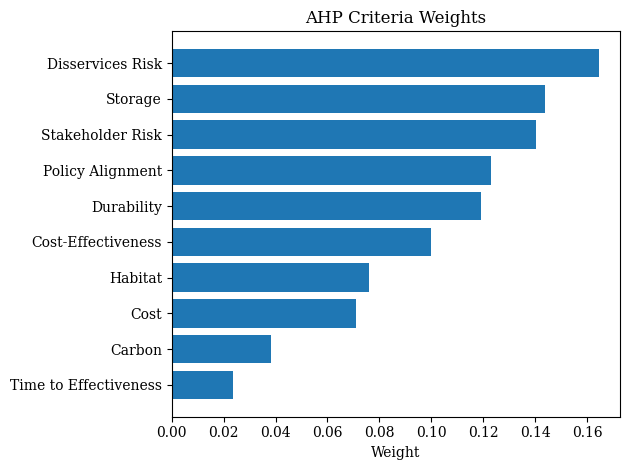

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort weights (so highest appears at top)
sorted_indices = np.argsort(weights)
sorted_criteria = [criteria[i] for i in sorted_indices]
sorted_weights = weights[sorted_indices] #sorted by number and size

plt.rcParams["font.family"] = "serif" #to match my dissertation, font can be altered here.
plt.figure() #plots graph

plt.barh(sorted_criteria, sorted_weights)

plt.xlabel("Weight")
plt.title("AHP Criteria Weights")

plt.tight_layout()
plt.show()

In [ ]:
interventions = [
    "Leaky Barriers",
    "Tree Planting",
    "Floodplain Reconnection",
    "Wet Woodland",
    "Riparian Buffer Strips",
    "Soil Management",
    "Flood Storage Areas",
    "Re-meandering",
    "Ponds and Wetlands",
    "Afforestation"
]

In [ ]:
print_subtitle("Nature Insights Scoring")

ni_mode = input(
    "How would you like to provide NI scores?\n"
    "1 - Input manually\n"
    "2 - Upload scoring file\n"
    "Enter 1 or 2: "
).strip()


------------------------------------------------------------
Nature Insights Scoring
------------------------------------------------------------
How would you like to provide NI scores?
1 - Input manually
2 - Upload scoring file
Enter 1 or 2: 1



## Step 3: NatureInsight Scoring

This stage captures performance scores for each intervention across the defined criteria, representing outputs derived from the ranked NatureInsight values or user-informed interpretation of those outputs.

Scores are assigned on a standardised **1–5 scale, which is custom to each intervention, unless follows a general approach. However, generally it follows this scale:**:
- 1 = Very low performance
- 5 = Very high performance

Users may enter **NA** if data is unavailable . These values are retained as missing data and excluded from aggregation where appropriate.

Uncertain values are shown in grey in the matrix, so **it is important to mark these with 'u'**, opposed to N/a. This is critical in understanding where there is a tool gap, or literature gap.

While default scoring system reflects the structure and intent of NatureInsight outputs, the framework allows for **user modification** to reflect:
- Local knowledge  
- Project-specific priorities  
- Alternative interpretations of intervention performance

# **Changes are welcomed.**

However, any adjustments should remain **grounded in industry guidance, literature, or practitioner judgement**, ensuring that scoring remains realistic, defensible, and comparable. This will also produce more accurate results!

Following, weight calculations are applied to support trade-off discussions.



In [ ]:
# these guides support consistent score giving across stakeholders and users, allowing compaability
#Make any changes to fit needs for specific project
# defaults are informed by literature and informed judgement
scoring_guides = {
    "Storage": [
        "1 = Negligible storage benefit",
        "2 = Minor storage potential",
        "3 = Moderate storage capacity",
        "4 = High storage capacity",
        "5 = Very high flood storage potential"
    ],

    "Cost": [
        "1 = Very high cost",
        "2 = High cost",
        "3 = Moderate cost",
        "4 = Low cost",
        "5 = Very low cost"
    ],

    "Habitat": [
        "1 = No habitat benefit",
        "2 = Limited habitat improvement",
        "3 = Moderate habitat benefit",
        "4 = High biodiversity gain",
        "5 = Significant ecosystem enhancement"
    ],

    "Carbon": [
        "1 = No carbon benefit",
        "2 = Low sequestration potential",
        "3 = Moderate carbon benefit",
        "4 = High sequestration potential",
        "5 = Very high carbon benefit"
    ]
}

In [ ]:

# Nature Insights Scoring

print_subtitle("Nature Insights Scoring")

ni_mode = input(
    "How would you like to provide NI scores?\n"
    "1 - Input manually\n"
    "2 - Upload scoring file\n"
    "Enter 1 or 2: "
).strip()



# OPTION 1: MANUAL INPUT

if ni_mode == "1":

    df_NI = pd.DataFrame(index=interventions, columns=criteria)

    for crit in criteria:
        print_subtitle(f"Scoring: {crit}")

        # Show custom guide if available
        if crit in scoring_guides:
            print("\nScoring guide:")
            for line in scoring_guides[crit]:
                print(line)
        else:
            print("1=Very low | 2=Low | 3=Moderate | 4=High | 5=Very high or enter N/a if no viable score")

        print()

        for inter in interventions:
            while True:
                value = input(f"{inter} (1–5 or NA): ").strip()

                if value.lower() in ["na", "x"]:
                    df_NI.loc[inter, crit] = np.nan
                    break

                try:
                    val = int(value)
                    if 1 <= val <= 5:
                        df_NI.loc[inter, crit] = val
                        break
                except:
                    pass

                print("Invalid input. Enter 1–5 or NA.")

    print("\nNI scoring completed.")



# OPTION 2: UPLOAD FILE

elif ni_mode == "2":

    from google.colab import files
    import io

    print("\nUpload your NI scoring file:")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]

    df_NI = pd.read_csv(io.BytesIO(uploaded[filename]), index_col=0)
    df_NI = df_NI.replace(["NA", "na", "", " "], np.nan) # read missing values properly

    print(f"\nFile '{filename}' successfully loaded.")



# ERROR HANDLING

else:
    raise ValueError("Invalid option. Please rerun and enter 1 or 2.")


------------------------------------------------------------
Nature Insights Scoring
------------------------------------------------------------
How would you like to provide NI scores?
1 - Input manually
2 - Upload scoring file
Enter 1 or 2: 1

------------------------------------------------------------
Scoring: Storage
------------------------------------------------------------

Scoring guide:
1 = Negligible storage benefit
2 = Minor storage potential
3 = Moderate storage capacity
4 = High storage capacity
5 = Very high flood storage potential

Leaky Barriers: 3
Tree Planting: 3
Floodplain Reconnection: 3
Wet Woodland: 3
Riparian Buffer Strips: 3
Soil Management: 3
Flood Storage Areas: 3
Re-meandering: 3
Ponds and Wetlands: 3
Afforestation: 3

------------------------------------------------------------
Scoring: Habitat
------------------------------------------------------------

Scoring guide:
1 = No habitat benefit
2 = Limited habitat improvement
3 = Moderate habitat benefit
4

## Step 4: Literature Scoring and Gap Matrix

This step allows comparison between NatureInsight outputs and literature-based expectations.

Users can:
- Input literature scores manually  
- Upload a scoring dataset  
- Use predefined literature datasets  

Missing values (NA) are supported to reflect uncertainty or lack of evidence.



In [ ]:

#  Literature Scoring Option

include_lit = input(
    "\nDo you want to include literature scoring and create a gap matrix? (y/n): "
).strip().lower() # provides the option for further exploration if wanted.

if include_lit == "y":

    print_subtitle("Literature Scoring")

    source_choice = input(
        "Choose literature scoring source:\n"
        "1 - Score yourself\n"
        "2 - Use predefined dataset\n"
        "Enter 1 or 2: "
    ).strip()


    # OPTION 1: USER DEFINES SCORES

    if source_choice == "1":

        method = input(
            "How would you like to provide scores?\n"
            "1 - Manual input\n"
            "2 - Upload scoring file\n"
            "Enter 1 or 2: "
        ).strip()


        # Manual scoring (same as NI)

        if method == "1":

            df_LIT = pd.DataFrame(index=interventions, columns=criteria)

            for crit in criteria:
                print_subtitle(f"Literature Scoring: {crit}")

                if crit in scoring_guides:
                    print("\nScoring guide:")
                    for line in scoring_guides[crit]:
                        print(line)
                else:
                    print("1=Very low | 2=Low | 3=Moderate | 4=High | 5=Very high")

                print("Enter 1–5 or 'NA' for missing data\n")

                for inter in interventions:
                    while True:
                        value = input(f"{inter}: ").strip()

                        if value.lower() in ["na", "x", ""]:
                            df_LIT.loc[inter, crit] = np.nan
                            break

                        try:
                            val = int(value)
                            if 1 <= val <= 5:
                                df_LIT.loc[inter, crit] = val
                                break
                        except:
                            pass

                        print("Invalid input. Enter 1–5 or NA.")

            print("\nLiterature scoring completed.")


        # Upload scoring

        elif method == "2":

            from google.colab import files
            import io

            print("\nUpload your literature scoring file:")
            uploaded = files.upload()

            filename = list(uploaded.keys())[0]
            df_LIT = pd.read_csv(io.BytesIO(uploaded[filename]), index_col=0)

            print(f"\nFile '{filename}' successfully loaded.")

        else:
            raise ValueError("Invalid selection.")


    # OPTION 2: PREDEFINED DATASET, made in advance according to NI interventions

    elif source_choice == "2":

        print("\nUsing predefined literature scoring dataset.")

        data = [
            # Storage, Habitat, Carbon, Cost, Cost-Effectiveness,
            # Time, Durability, Stakeholder Risk, Policy, Disservices
            [4, 3, 2, 4, 4, 4, 3, 3, 4, 3],  # Runoff Attenuation Feature
      [5, 5, 3, 2, 4, 2, 4, 4, 5, 3],  # Floodplain Reconnection
        [3, 4, 2, 5, 5, 4, 3, 3, 4, 4],  # Large Woody Debris
        [3, 5, 5, 3, 4, 2, 3, 3, 5, 3],  # Tree Planting
        [4, 5, 4, 2, 3, 2, 3, 3, 5, 3],  # Wet Woodland
        [3, 4, 3, 4, 4, 4, 3, 2, 4, 2],  # Buffer Strip
        [3, 3, 3, 4, 4, 2, 3, 3, 4, 2],  # Soil Management
        [4, 5, 5, 2, 3, 1, 3, 3, 5, 3],  # Peat Management
        [4, 4, 4, 3, 3, 3, 3, 3, 4, 3],  # Gully Stuffing
        [4, 4, 4, 2, 3, 3, 3, 4, 4, 4],  # Grip Blocking
        ]

        df_LIT = pd.DataFrame(data, index=interventions, columns=criteria)

        print_subtitle("Predefined Literature Scores, Please Note this has no gaps, and will vary from sources, which were found to be highly variable in this process")
        print(df_LIT)

# ============================================================
# NO LITERATURE

elif include_lit == "n":
    df_LIT = None

else:
    raise ValueError("Invalid input. Enter y or n.")


Do you want to include literature scoring and create a gap matrix? (y/n): y

------------------------------------------------------------
Literature Scoring
------------------------------------------------------------
Choose literature scoring source:
1 - Score yourself
2 - Use predefined dataset
Enter 1 or 2: 2

Using predefined literature scoring dataset.

------------------------------------------------------------
Predefined Literature Scores, Please Note this has no gaps, and will vary from sources, which were found to be highly variable in this process
------------------------------------------------------------
                         Storage  Habitat  Carbon  Cost  Cost-Effectiveness  \
Leaky Barriers                 4        3       2     4                   4   
Tree Planting                  5        5       3     2                   4   
Floodplain Reconnection        3        4       2     5                   5   
Wet Woodland                   3        5       5     3  

In [ ]:
if route == "1":
    ...
elif route == "2":
    ...
elif route == "3":
    ...

In [ ]:
#confirm correct weighting score before proceeding
# Use weighting route selected earlier

print_subtitle("Weighting Source")

if route == "1":
    print("Using preset weighting selected earlier.")

elif route == "2":
    print("Using uploaded weighting or pairwise matrix selected earlier.")

elif route == "3":
    print("Using AHP weighting created earlier.")

else:
    raise ValueError("Invalid route selected earlier.")


------------------------------------------------------------
Weighting Source
------------------------------------------------------------
Using preset weighting selected earlier.


# **Weight outputted here as a check point.**

In [ ]:
weights

array([0.1439 , 0.07613, 0.0383 , 0.071  , 0.0999 , 0.0235 , 0.1193 ,
       0.1402 , 0.123  , 0.1645 ])

In [ ]:

# Apply weights with NA normalisation
#this helps address missing values, and ensured weighting is distributed as in practice.

def weighted_score(row, weights):
  #find weighted score per interventions
  #prevents bias from incomplete scoring
    row = row.astype(float) #ensures the format is numeric
    mask = ~np.isnan(row)
    #Sources any non Na values

    if np.sum(mask) == 0:
        return np.nan

    return np.sum(row[mask] * weights[mask]) / np.sum(weights[mask]) #ensures weights only applied where applicable, and is normalised for fairness an validity if not.

df_scores_final = df_NI.copy() # combine df_scores_final with NI scores

df_scores_final["Weighted Score"] = df_scores_final.apply(
    lambda row: weighted_score(row.values, weights),
    axis=1 #apply weighting to all to refelct priorities
)
#rank the interventions to provide clarity for best options
df_scores_final["Rank"] = df_scores_final["Weighted Score"].rank(ascending=False)

print_subtitle("Final Weighted Results")
print(df_scores_final.sort_values(by="Rank"))
print(df_scores_final.round(4))


------------------------------------------------------------
Final Weighted Results
------------------------------------------------------------
                        Storage Habitat Carbon Cost Cost-Effectiveness  \
Leaky Barriers                3       3      3    3                  3   
Tree Planting                 3       3      3    3                  3   
Floodplain Reconnection       3       3      3    3                  3   
Wet Woodland                  3       3      3    3                  3   
Riparian Buffer Strips        3       3      3    3                  3   
Soil Management               3       3      3    3                  3   
Flood Storage Areas           3       3      3    3                  3   
Re-meandering                 3       3      3    3                  3   
Ponds and Wetlands            3       3      3    3                  3   
Afforestation                 3       3      3    3                  3   

                        Time to Effecti

# **Step 5: Weighted Comparison and Gap Analysis**

This stage integrates NatureInsight (NI) scoring and literature-based scoring to enable direct comparison between tool outputs and expected performance.

Two outputs are produced:

- **Detailed comparison table**  
  Shows NI scores, literature scores, and criterion-level gaps  

- **Weighted summary table**  
  Aggregates results using AHP-derived weights to produce:
  - NI performance score  
  - Literature benchmark score  
  - Gap score (NI vs Literature)  

Missing values are handled using adaptive normalisation, ensuring results remain robust where data is incomplete.

This enables identification of where NatureInsight may overestimate or underestimate intervention performance. Also, it identifies where gaps, unknowns and uncertains exist.



In [ ]:

# Create a weighted comparison tables
#prepare the numeric data

# Make sure NI and Literature scores are numeric before proceeding
df_NI_num = df_NI.apply(pd.to_numeric, errors="coerce")

if df_LIT is not None:
    df_LIT_num = df_LIT.apply(pd.to_numeric, errors="coerce") #converts NA
else:
    df_LIT_num = None


# Function output: weighted score with NA normalisation
def weighted_score(row, weights): #finds the weighted score using AHP weights
    row = np.array(row, dtype=float) #converts NA values correctly
    mask = ~np.isnan(row) # a true of false filter effectively, where missing values are found.

    if np.sum(mask) == 0:
        return np.nan #handles missing values correctly

    return np.sum(row[mask] * weights[mask]) / np.sum(weights[mask]) #weights applied to numerical values and multiplied by respective weights.


#Create weighted summary table, comparing NI and literature

if df_LIT_num is not None:
    df_compare = pd.DataFrame(index=interventions)

    for i, crit in enumerate(criteria):
        ni_vals = df_NI_num[crit]
        lit_vals = df_LIT_num[crit]
        gap_vals = ni_vals - lit_vals #this finds the gap matrix values themself, ie. the difference in NI and Literature scores

        df_compare[f"{crit} NI"] = ni_vals
        df_compare[f"{crit} Lit"] = lit_vals
        df_compare[f"{crit} Gap"] = gap_vals

else:
    df_compare = df_NI_num.copy() #if n was chisen for literature, jsut display Ni scores, without the gap





df_summary = pd.DataFrame(index=interventions)

# NI weighted score
df_summary["NI Weighted Score"] = df_NI_num.apply(
    lambda row: weighted_score(row.values, weights), axis=1
)

# Literature weighted score
if df_LIT_num is not None:
    df_summary["Literature Weighted Score"] = df_LIT_num.apply(
        lambda row: weighted_score(row.values, weights), axis=1
    )

    # Gap weighted score
    df_gap_num = df_NI_num - df_LIT_num
    df_summary["Gap Weighted Score"] = df_gap_num.apply(
        lambda row: weighted_score(row.values, weights), axis=1
    )

# Rank by NI weighted score by default
#higher is better, for readability
df_summary["Rank"] = df_summary["NI Weighted Score"].rank(
    ascending=False,
    method="dense"
).astype(int)



# Round for cleaner display, but not too conservatively

df_compare = df_compare.round(3)
df_summary = df_summary.round(3)



# Step: Show outputs

print_subtitle("Detailed Comparison Table")
print(df_compare)

print_subtitle("Weighted Summary Table")
print(df_summary.sort_values(by="NI Weighted Score", ascending=False))


------------------------------------------------------------
Detailed Comparison Table
------------------------------------------------------------
                         Storage NI  Storage Lit  Storage Gap  Habitat NI  \
Leaky Barriers                    3            4           -1           3   
Tree Planting                     3            5           -2           3   
Floodplain Reconnection           3            3            0           3   
Wet Woodland                      3            3            0           3   
Riparian Buffer Strips            3            4           -1           3   
Soil Management                   3            3            0           3   
Flood Storage Areas               3            3            0           3   
Re-meandering                     3            4           -1           3   
Ponds and Wetlands                3            4           -1           3   
Afforestation                     3            4           -1           3   

   

# **Output: Cleaner table of comaprisons**

The following tables present the final outputs of the analysis:

- **Detailed Comparison Table**  
  Displays criterion-level scores for NatureInsight (NI) and literature, alongside calculated gaps.

- **Weighted Summary Table**  
  Provides aggregated scores using AHP-derived weights, including:
  - NI performance
  - Literature benchmark (if available)
  - Weighted gap
  - Overall ranking

Results are sorted by weighted score to highlight the highest-performing interventions.

In [ ]:

# Display clean tables for readability


print_subtitle("Detailed Comparison Table")
display(df_compare) #literature vs NI output

print_subtitle("Weighted Summary Table")
# Sort results by NI performance (highest first)
display(df_summary.sort_values(by="NI Weighted Score", ascending=False))
print_note("Higher scores indicate better overall performance based on selected weighting.")


------------------------------------------------------------
Detailed Comparison Table
------------------------------------------------------------


,Storage NI,Storage Lit,Storage Gap,Habitat NI,Habitat Lit,Habitat Gap,Carbon NI,Carbon Lit,Carbon Gap,Cost NI,...,Durability Gap,Stakeholder Risk NI,Stakeholder Risk Lit,Stakeholder Risk Gap,Policy Alignment NI,Policy Alignment Lit,Policy Alignment Gap,Disservices Risk NI,Disservices Risk Lit,Disservices Risk Gap
Leaky Barriers,3,4,-1,3,3,0,3,2,1,3,...,0,3,3,0,3,4,-1,3,3,0
Tree Planting,3,5,-2,3,5,-2,3,3,0,3,...,-1,3,4,-1,3,5,-2,3,3,0
Floodplain Reconnection,3,3,0,3,4,-1,3,2,1,3,...,0,3,3,0,3,4,-1,3,4,-1
Wet Woodland,3,3,0,3,5,-2,3,5,-2,3,...,0,3,3,0,3,5,-2,3,3,0
Riparian Buffer Strips,3,4,-1,3,5,-2,3,4,-1,3,...,0,3,3,0,3,5,-2,3,3,0
Soil Management,3,3,0,3,4,-1,3,3,0,3,...,0,3,2,1,3,4,-1,3,2,1
Flood Storage Areas,3,3,0,3,3,0,3,3,0,3,...,0,3,3,0,3,4,-1,3,2,1
Re-meandering,3,4,-1,3,5,-2,3,5,-2,3,...,0,3,3,0,3,5,-2,3,3,0
Ponds and Wetlands,3,4,-1,3,4,-1,3,4,-1,3,...,0,3,3,0,3,4,-1,3,3,0
Afforestation,3,4,-1,3,4,-1,3,4,-1,3,...,0,3,4,-1,3,4,-1,3,4,-1



------------------------------------------------------------
Weighted Summary Table
------------------------------------------------------------


,NI Weighted Score,Literature Weighted Score,Gap Weighted Score,Rank
Leaky Barriers,3.0,3.423,-0.423,1
Tree Planting,3.0,3.951,-0.951,1
Floodplain Reconnection,3.0,3.691,-0.691,1
Wet Woodland,3.0,3.551,-0.551,1
Riparian Buffer Strips,3.0,3.486,-0.486,1
Soil Management,3.0,3.089,-0.089,1
Flood Storage Areas,3.0,3.106,-0.106,1
Re-meandering,3.0,3.501,-0.501,1
Ponds and Wetlands,3.0,3.381,-0.381,1
Afforestation,3.0,3.615,-0.615,1



Note: Higher scores indicate better overall performance based on selected weighting.


In [ ]:

# Export formatted Excel

output_file = "Weighted_Results.xlsx" # output file name to see.
# create excel writer using openpyxl
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_compare.to_excel(writer, sheet_name="Comparison Table") #comparison table
    df_summary.sort_values(by="NI Weighted Score", ascending=False).to_excel(
        writer, sheet_name="Weighted Summary"
    )

    wb = writer.book


    # Format Comparison Table sheet
    ws1 = writer.sheets["Comparison Table"]
    ws1.freeze_panes = "B2" #freezes the row for readability

    # Auto-adjust column widths to fit well

    for col in ws1.columns:
        max_length = 0
        col_letter = col[0].column_letter
        for cell in col:
            try:
                max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws1.column_dimensions[col_letter].width = max_length + 2

    # Format Weighted Summary sheet
    ws2 = writer.sheets["Weighted Summary"] #freeze top row again
    ws2.freeze_panes = "B2"

    for col in ws2.columns:
        max_length = 0
        col_letter = col[0].column_letter
        for cell in col:
            try:
                max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws2.column_dimensions[col_letter].width = max_length + 2

print(f"Formatted Excel file created: {output_file}") #confirms the file

Formatted Excel file created: Weighted_Results.xlsx


In [ ]:
df_summary_sorted = df_summary.sort_values(by="NI Weighted Score", ascending=False).round(3)
display(df_summary_sorted)

,NI Weighted Score,Literature Weighted Score,Gap Weighted Score,Rank
Leaky Barriers,3.0,3.423,-0.423,1
Tree Planting,3.0,3.951,-0.951,1
Floodplain Reconnection,3.0,3.691,-0.691,1
Wet Woodland,3.0,3.551,-0.551,1
Riparian Buffer Strips,3.0,3.486,-0.486,1
Soil Management,3.0,3.089,-0.089,1
Flood Storage Areas,3.0,3.106,-0.106,1
Re-meandering,3.0,3.501,-0.501,1
Ponds and Wetlands,3.0,3.381,-0.381,1
Afforestation,3.0,3.615,-0.615,1


In [ ]:
from google.colab import files
files.download("Weighted_Results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# Create comparison matrix
df_compare = pd.DataFrame(index=interventions)


for crit in criteria:
    df_compare[f"{crit} NI"] = df_NI[crit]
    df_compare[f"{crit} Lit"] = df_LIT[crit]
    df_compare[f"{crit} Gap"] = pd.to_numeric(df_NI[crit], errors="coerce") - pd.to_numeric(df_LIT[crit], errors="coerce")

print_subtitle("NI vs Literature Comparison Matrix")
print(df_compare)


------------------------------------------------------------
NI vs Literature Comparison Matrix
------------------------------------------------------------
                        Storage NI  Storage Lit  Storage Gap Habitat NI  \
Leaky Barriers                   3            4           -1          3   
Tree Planting                    3            5           -2          3   
Floodplain Reconnection          3            3            0          3   
Wet Woodland                     3            3            0          3   
Riparian Buffer Strips           3            4           -1          3   
Soil Management                  3            3            0          3   
Flood Storage Areas              3            3            0          3   
Re-meandering                    3            4           -1          3   
Ponds and Wetlands               3            4           -1          3   
Afforestation                    3            4           -1          3   

                

In [ ]:

# Create final comparison table
# Only run comparison if literature data exists
if df_LIT is not None:
    df_compare = pd.DataFrame(index=interventions)

    for crit in criteria:
        ni_vals = pd.to_numeric(df_NI[crit], errors="coerce")
        lit_vals = pd.to_numeric(df_LIT[crit], errors="coerce")

        df_compare[f"{crit} NI"] = ni_vals
        df_compare[f"{crit} Lit"] = lit_vals
        df_compare[f"{crit} Gap"] = ni_vals - lit_vals

else:
    df_compare = df_NI.copy() # If no literature data, fall back to NI scores only
print_subtitle("NI vs Literature Comparison Matrix")
print(df_compare)


------------------------------------------------------------
NI vs Literature Comparison Matrix
------------------------------------------------------------
                         Storage NI  Storage Lit  Storage Gap  Habitat NI  \
Leaky Barriers                    3            4           -1           3   
Tree Planting                     3            5           -2           3   
Floodplain Reconnection           3            3            0           3   
Wet Woodland                      3            3            0           3   
Riparian Buffer Strips            3            4           -1           3   
Soil Management                   3            3            0           3   
Flood Storage Areas               3            3            0           3   
Re-meandering                     3            4           -1           3   
Ponds and Wetlands                3            4           -1           3   
Afforestation                     3            4           -1           